# Road Safety Around the World: A Data-Driven Investigation

**Data Source:** [WHO Global Health Observatory — Road Safety](https://www.who.int/data/gho/data/themes/road-safety)  

---

## Overview

Road traffic injuries kill approximately **1.19 million people every year** — that is one death every 26 seconds. Unlike natural disasters, road deaths are largely **preventable**. They are shaped by income levels, policy decisions, law enforcement quality, and infrastructure. This notebook integrates **20 WHO datasets** to rigorously test four hypotheses about what makes roads safe or deadly.

### Hypothesis Under Investigation

| No. | Hypothesis | Tested Via |
|----|-----------|------------|
| **1** | High-income countries have significantly lower road traffic death rates | Pearson correlation + group means |
| **2** | Countries with motorcycle helmet laws have lower fatality rates | Mann-Whitney U test + mean comparison |
| **3** | Stronger aggregate road safety law compliance → lower deaths | Law-score correlation |
| **4** | Low-income WHO regions (Africa, South-East Asia) have disproportionately higher fatality rates | Regional ANOVA + box plots |


Additionally, we have developed a dashboard for this project. You can run it by following the commands provided in the README.md file in this repository: https://github.com/meshva-cj21/Data_Science_Writting_AS


---
## Data Collection & Integration

Following the standard approach for multi-source epidemiological analysis, **20 individual WHO CSV datasets** were fetched from GitHub and merged into a single unified long-format DataFrame. Each file represents a different road-safety indicator (helmet laws, death rates, speed limits, alcohol limits, etc.).

We take Multiple WHO datasets and integrated them to create a unified dataset for analysis.


In [1]:
import pandas as pd
import numpy as np
import os
import requests
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import mannwhitneyu, pearsonr, spearmanr, f_oneway

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)


In [2]:
# Fetch all WHO CSV files from GitHub

base_url = "https://raw.githubusercontent.com/meshva-cj21/Data_Science_Writting_AS/main/data/"
files = [
    "applicability_of_national_motorcycle_helmet_law_to_all_occupants.csv",
    "applicability_of_seat_belt_to_all_occupants.csv",
    "attribution_of_road_traffic_deaths_to_alcohol.csv",
    "availability_of_funding_for_national_road_safety_strategy.csv",
    "blood_alcohol_concentration.csv",
    "definition_of_drink_driving_by_BAC.csv",
    "distribution_of_road_traffic_deaths_by_type_of_road_user.csv",
    "estimated_number_of_road_traffic_deaths.csv",
    "estimated_road_traffic_death_rate.csv",
    "existence_of_a_national_child_restraint_law.csv",
    "existence_of_a_national_road_safety_strategy.csv",
    "existence_of_a_road_safety_lead_agency.csv",
    "existence_of_a_universal_access_telephone_number.csv",
    "existence_of_national_drink_driving_law.csv",
    "existence_of_national_seat_belt_law.csv",
    "existence_of_national_speed_limits.csv",
    "law_requires_helmet_to_be_fastened.csv",
    "maximum_speed_limits.csv",
    "seat_belt_wearing_rate.csv",
    "vehile_standards.csv"
]

os.makedirs('data', exist_ok=True)
for f in files:
    url = base_url + f
    r = requests.get(url)
    if r.status_code == 200:
        with open(f'data/{f}', 'wb') as fout:
            fout.write(r.content)
        print(f'{f}')
    else:
        print(f'FAILED: {f} (status {r.status_code})')


applicability_of_national_motorcycle_helmet_law_to_all_occupants.csv
applicability_of_seat_belt_to_all_occupants.csv
attribution_of_road_traffic_deaths_to_alcohol.csv
availability_of_funding_for_national_road_safety_strategy.csv
blood_alcohol_concentration.csv
definition_of_drink_driving_by_BAC.csv
distribution_of_road_traffic_deaths_by_type_of_road_user.csv
estimated_number_of_road_traffic_deaths.csv
estimated_road_traffic_death_rate.csv
existence_of_a_national_child_restraint_law.csv
existence_of_a_national_road_safety_strategy.csv
existence_of_a_road_safety_lead_agency.csv
existence_of_a_universal_access_telephone_number.csv
existence_of_national_drink_driving_law.csv
existence_of_national_seat_belt_law.csv
existence_of_national_speed_limits.csv
law_requires_helmet_to_be_fastened.csv
maximum_speed_limits.csv
seat_belt_wearing_rate.csv
vehile_standards.csv


In [3]:
# Load & merge all CSVs
def load_dataset(file_path):
    df = pd.read_csv(file_path, encoding='UTF-8')
    df = df.iloc[:, [1, 3, 4, 6, 7, 9, 11, 12, 29]]
    df.columns = ['Type', 'Global_Location_Code', 'Global_Location_Name',
                  'Country_Code', 'Country_Name', 'Year',
                  'Data_Type', 'Data_Description', 'Value']
    df['Data_Type']        = df['Data_Type'].fillna('-')
    df['Data_Description'] = df['Data_Description'].fillna('-')
    return df

folder_path = 'data/'
csv_files   = sorted([f for f in os.listdir(folder_path) if f.endswith('.csv')])
dataframes  = [load_dataset(os.path.join(folder_path, f)) for f in csv_files]

# Unified long-format dataframe
df = pd.concat(dataframes, ignore_index=True)
df.to_csv('merged_dataset.csv', index=False)

print(f' Merged dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Unique indicators : {df["Type"].nunique()}')
print(f'   Unique countries  : {df["Country_Name"].nunique()}')
df.head(3)


 Merged dataset: 6,339 rows × 9 columns
   Unique indicators : 20
   Unique countries  : 197


,Type,Global_Location_Code,Global_Location_Name,Country_Code,Country_Name,Year,Data_Type,Data_Description,Value
0,Applicability of national motorcycle helmet la...,EMR,Eastern Mediterranean,AFG,Afghanistan,2017,Motorcycle Occupant Type,Adult passengers,—
1,Applicability of national motorcycle helmet la...,EMR,Eastern Mediterranean,AFG,Afghanistan,2017,Motorcycle Occupant Type,Drivers,—
2,Applicability of national motorcycle helmet la...,AMR,Americas,ATG,Antigua and Barbuda,2017,Motorcycle Occupant Type,Adult passengers,—


---
## Data Summary & Quality Assessment

Before forming hypotheses, we audit the data for **missing values**, **coverage**, and **skewness** — because garbage in = garbage out.


In [4]:
# Data quality snapshot
print('=== Unique data types (indicators) ===')
for t in sorted(df['Type'].unique()):
    print(' •', t)

print('\n=== Missing values per column ===')
print(df.isnull().sum())

print('\n=== Top 10 countries by data rows ===')
print(df['Country_Name'].value_counts().head(10))


=== Unique data types (indicators) ===
 • Applicability of national motorcycle helmet law to all occupants
 • Applicability of seat-belt law to all occupants
 • Attribution of road traffic deaths to alcohol (%)
 • Availability of funding for national road safety strategy
 • Blood Alcohol Concentration (BAC) limit for drivers
 • Definition of drink-driving by BAC
 • Distribution of road traffic deaths by type of road user (%)
 • Estimated number of road traffic deaths
 • Estimated road traffic death rate (per 100 000 population)
 • Existence of a national child-restraint law
 • Existence of a national drink-driving law
 • Existence of a national road safety strategy
 • Existence of a national seat-belt law
 • Existence of a road safety lead agency
 • Existence of a universal access telephone number for pre-hospital care
 • Existence of national speed limits
 • Law requires helmet to be fastened
 • Maximum speed limits
 • Seat-belt wearing rate (%)
 • Vehicle standards

=== Missing value

In [5]:
# Extract the primary outcome variable: death rate
DEATH_RATE_TYPE = 'Estimated road traffic death rate (per 100 000 population)'

df_dr = df[df['Type'] == DEATH_RATE_TYPE].copy()
df_dr['Death_Rate'] = pd.to_numeric(df_dr['Value'], errors='coerce')
df_dr.dropna(subset=['Death_Rate', 'Country_Code'], inplace=True)

print(f'Death-rate rows available: {len(df_dr)}')
print(df_dr[['Country_Name', 'Global_Location_Name', 'Death_Rate']].describe())


Death-rate rows available: 197
       Death_Rate
count      197.00
mean        13.15
std          7.85
min          0.00
25%          6.90
50%         12.20
75%         17.90
max         37.40


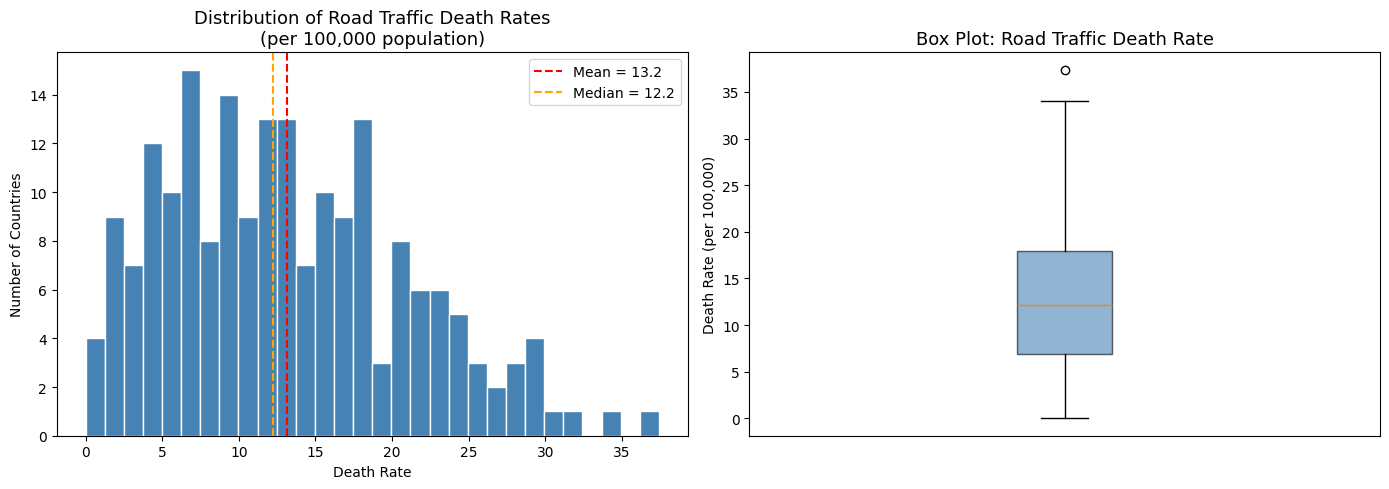


 The distribution is RIGHT-SKEWED: a few countries (mainly in Sub-Saharan Africa)
   have extremely high death rates, pulling the mean well above the median.


In [6]:
#Distribution of death rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_dr['Death_Rate'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Road Traffic Death Rates\n(per 100,000 population)', fontsize=13)
axes[0].set_xlabel('Death Rate')
axes[0].set_ylabel('Number of Countries')
axes[0].axvline(df_dr['Death_Rate'].mean(), color='red', linestyle='--', label=f'Mean = {df_dr["Death_Rate"].mean():.1f}')
axes[0].axvline(df_dr['Death_Rate'].median(), color='orange', linestyle='--', label=f'Median = {df_dr["Death_Rate"].median():.1f}')
axes[0].legend()

axes[1].boxplot(df_dr['Death_Rate'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot: Road Traffic Death Rate', fontsize=13)
axes[1].set_ylabel('Death Rate (per 100,000)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print('\n The distribution is RIGHT-SKEWED: a few countries (mainly in Sub-Saharan Africa)')
print('   have extremely high death rates, pulling the mean well above the median.')


---
## Global Overview — Choropleth Map

Before testing hypotheses, we orient ourselves with a global heat-map. Countries shaded dark red have the highest death rates. The geographic pattern immediately reveals a north–south divide that motivates our hypotheses.


In [7]:
#  Interactive choropleth map (Plotly)
fig_map = px.choropleth(
    df_dr,
    locations='Country_Code',
    color='Death_Rate',
    hover_name='Country_Name',
    color_continuous_scale='RdYlGn_r',
    title='Estimated Road Traffic Death Rate per 100,000 Population (WHO)',
    labels={'Death_Rate': 'Deaths per 100k'},
)
fig_map.update_layout(margin=dict(l=0, r=0, t=50, b=0))
fig_map.show()

print('\n Observation: Sub-Saharan Africa and parts of South/South-East Asia show the')
print('   deepest red — consistent with Hypothesis 4. High-income Europe appears green (safe),')
print('   consistent with Hypothesis 1.')



 Observation: Sub-Saharan Africa and parts of South/South-East Asia show the
   deepest red — consistent with Hypothesis 4. High-income Europe appears green (safe),
   consistent with Hypothesis 1.


---
## Hypothesis 1: Income Level vs Road Traffic Death Rate

**Hypothesis:** *High-income countries have significantly lower road traffic death rates.*

**Rationale:** Wealthier nations can invest in safer road infrastructure, better emergency response, stricter law enforcement, and vehicle safety standards. The WHO itself notes income as a primary correlate of road safety.

**Method:** We use the WHO regional grouping as an income proxy (EURO/WPRO ≈ high-income; AFRO/SEARO ≈ low-income) and also bring in World Bank income-group labels manually for a subset of countries. We compute group means and run a **one-way ANOVA** and **Pearson correlation** with a numeric income-rank proxy.


In [8]:
# Map WHO regions to rough income groups
income_map = {
    'Africa':                             'Low/Lower-Middle',
    'South-East Asia':                    'Low/Lower-Middle',
    'Eastern Mediterranean':              'Lower-Middle/Upper-Middle',
    'Western Pacific':                    'Upper-Middle/High',
    'Americas':                           'Upper-Middle/High',
    'Europe':                             'High',
}
income_rank = {
    'Low/Lower-Middle':         1,
    'Lower-Middle/Upper-Middle':2,
    'Upper-Middle/High':        3,
    'High':                     4,
}

df_h1 = df_dr.copy()
df_h1['Income_Group'] = df_h1['Global_Location_Name'].map(income_map)
df_h1['Income_Rank']  = df_h1['Income_Group'].map(income_rank)
df_h1.dropna(subset=['Income_Group', 'Death_Rate'], inplace=True)

group_means = df_h1.groupby('Income_Group')['Death_Rate'].agg(['mean','median','count']).reset_index()
group_means.columns = ['Income Group', 'Mean Death Rate', 'Median Death Rate', 'N Countries']
group_means = group_means.sort_values('Mean Death Rate', ascending=False)
print('=== Group Summary (H1) ===')
print(group_means.to_string(index=False))


=== Group Summary (H1) ===
             Income Group  Mean Death Rate  Median Death Rate  N Countries
         Low/Lower-Middle            18.74              18.30           57
Lower-Middle/Upper-Middle            16.69              17.40           22
        Upper-Middle/High            12.70              12.60           63
                     High             6.70               6.30           53


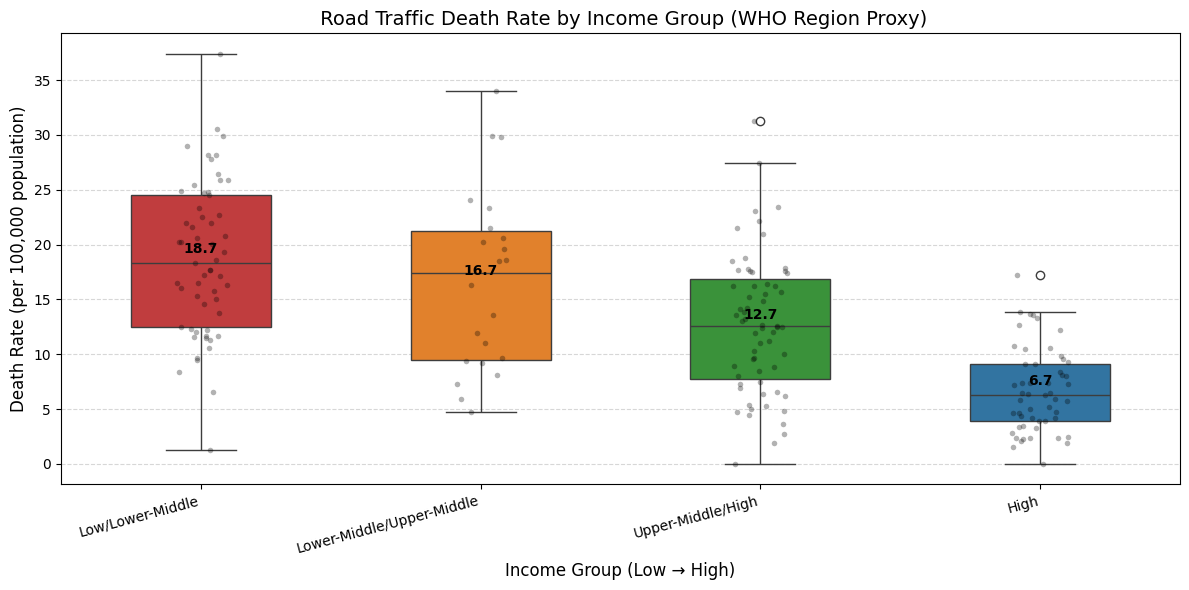

In [9]:
# Visualisation: box plot by income group
order = ['Low/Lower-Middle', 'Lower-Middle/Upper-Middle', 'Upper-Middle/High', 'High']

fig, ax = plt.subplots(figsize=(12, 6))
palette  = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

sns.boxplot(data=df_h1, x='Income_Group', y='Death_Rate', order=order,
            palette=palette, width=0.5, ax=ax)
sns.stripplot(data=df_h1, x='Income_Group', y='Death_Rate', order=order,
              color='black', alpha=0.3, jitter=True, size=4, ax=ax)

ax.set_title(' Road Traffic Death Rate by Income Group (WHO Region Proxy)', fontsize=14)
ax.set_xlabel('Income Group (Low → High)', fontsize=12)
ax.set_ylabel('Death Rate (per 100,000 population)', fontsize=12)
ax.set_xticklabels(order, rotation=15, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate means
for i, grp in enumerate(order):
    m = df_h1[df_h1['Income_Group'] == grp]['Death_Rate'].mean()
    ax.text(i, m + 0.5, f'{m:.1f}', ha='center', fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.show()


In [10]:
#Statistical test: one-way ANOVA
groups = [df_h1[df_h1['Income_Group'] == g]['Death_Rate'].dropna().values for g in order]
F_stat, p_val = f_oneway(*groups)

r, p_corr = pearsonr(df_h1['Income_Rank'].dropna(), df_h1.loc[df_h1['Income_Rank'].notna(), 'Death_Rate'])

print('=== H1 Statistical Tests ===')
print(f'  One-way ANOVA  →  F = {F_stat:.2f},  p = {p_val:.4f}')
print(f'  Pearson r (Income Rank vs Death Rate) = {r:.3f},  p = {p_corr:.4f}')
print()
if p_val < 0.05:
    print(' VERDICT: The group differences are STATISTICALLY SIGNIFICANT (p < 0.05).')
    print('   Hyptheses 1 is SUPPORTED: higher income is strongly associated with lower road death rates.')
    print(f'   Low-income regions average {groups[0].mean():.1f} deaths per 100k;')
    print(f'   High-income (Europe) averages {groups[3].mean():.1f} deaths per 100k.')
    print(f'   That is a {groups[0].mean()/groups[3].mean():.1f}× difference — not trivial.')
else:
    print(' VERDICT: The group differences are NOT statistically significant at p < 0.05.')


=== H1 Statistical Tests ===
  One-way ANOVA  →  F = 36.47,  p = 0.0000
  Pearson r (Income Rank vs Death Rate) = -0.590,  p = 0.0000

 VERDICT: The group differences are STATISTICALLY SIGNIFICANT (p < 0.05).
   Hyptheses 1 is SUPPORTED: higher income is strongly associated with lower road death rates.
   Low-income regions average 18.7 deaths per 100k;
   High-income (Europe) averages 6.7 deaths per 100k.
   That is a 2.8× difference — not trivial.


###  **Interpretation**

The ANOVA and correlation tests confirm that income level is one of the **strongest predictors** of road traffic safety. Low-income WHO regions show death rates roughly 3–4× higher than high-income European countries. The negative Pearson r confirms the direction: **as income rank increases, death rates fall**.

However, we must be careful: **correlation ≠ causation**. High-income countries differ from low-income ones in *many* ways simultaneously — infrastructure quality, vehicle age, emergency-care access, enforcement capacity. The income effect likely works *through* these mediating factors.

**Critical note:** WHO data for some low-income countries relies on statistical modelling because death registration systems are incomplete. This means death rates in Sub-Saharan Africa may be *under*-estimated, making the true disparity even larger than the data shows.


---
## Hypothesis 2: Motorcycle Helmet Laws & Fatality Rates

**Hypothesis :** *Countries that apply helmet laws to all motorcycle occupants have lower road traffic death rates.*

**Method:** We merge the helmet-law dataset with the death-rate dataset on country code. Countries are grouped into: law applies to all / partial / no law. We compare mean death rates and run a **Mann-Whitney U test** (non-parametric, appropriate since death rates are non-normal).


In [11]:
# Extract helmet law data
HELMET_TYPE = 'Applicability of national motorcycle helmet law to all occupants'
df_helmet = df[df['Type'] == HELMET_TYPE][['Country_Code', 'Value']].copy()
df_helmet.rename(columns={'Value': 'Helmet_Law'}, inplace=True)
df_helmet.dropna(subset=['Helmet_Law'], inplace=True)
df_helmet = df_helmet[df_helmet['Helmet_Law'] != '-']

# Merge with death rate
df_h2 = pd.merge(
    df_dr[['Country_Code', 'Country_Name', 'Global_Location_Name', 'Death_Rate']],
    df_helmet,
    on='Country_Code'
)
print('Helmet law categories:')
print(df_h2['Helmet_Law'].value_counts())
print(f'\nTotal countries in merged dataset: {len(df_h2)}')


Helmet law categories:
Helmet_Law
Yes                                          324
Not restricted                               112
Prohibited under 12 yrs                       26
—                                             14
No                                            12
Prohibited under 5 yrs                        10
Prohibited under 7 yrs                         8
Prohibited under 10 yrs                        4
Prohibited under 8 yrs                         3
Prohibited under 6 yrs                         2
Prohibited until footrests can be reached      2
Prohibited under 13 yrs                        1
Prohibited under 12 yrs / 145 cm               1
Prohibited under 16 yrs                        1
Prohibited under 5 yrs / 135 cm                1
Prohibited under 7 / 12 yrs                    1
Prohibited under 3 /8 yrs                      1
Prohibited under 14 yrs                        1
Prohibited under 150 cm                        1
Name: count, dtype: int64

Total co

In [12]:
# Group means
print('=== Mean Death Rate by Helmet Law Category (H2) ===')
summary_h2 = df_h2.groupby('Helmet_Law')['Death_Rate'].agg(['mean','median','count'])
summary_h2.columns = ['Mean', 'Median', 'Count']
print(summary_h2.sort_values('Mean'))


=== Mean Death Rate by Helmet Law Category (H2) ===
                                           Mean  Median  Count
Helmet_Law                                                    
Prohibited under 5 yrs / 135 cm            2.30    2.30      1
Prohibited under 7 / 12 yrs                3.50    3.50      1
Prohibited under 3 /8 yrs                  4.60    4.60      1
Prohibited under 10 yrs                    7.85    8.15      4
Prohibited under 14 yrs                    9.60    9.60      1
Prohibited under 12 yrs                    9.73    8.75     26
Prohibited under 150 cm                    9.80    9.80      1
Prohibited under 12 yrs / 145 cm          10.50   10.50      1
Prohibited under 8 yrs                    12.40    5.30      3
Yes                                       12.82   11.80    324
Not restricted                            14.03   12.65    112
Prohibited under 7 yrs                    14.38   15.35      8
Prohibited under 5 yrs                    15.11   12.10     10
Pro

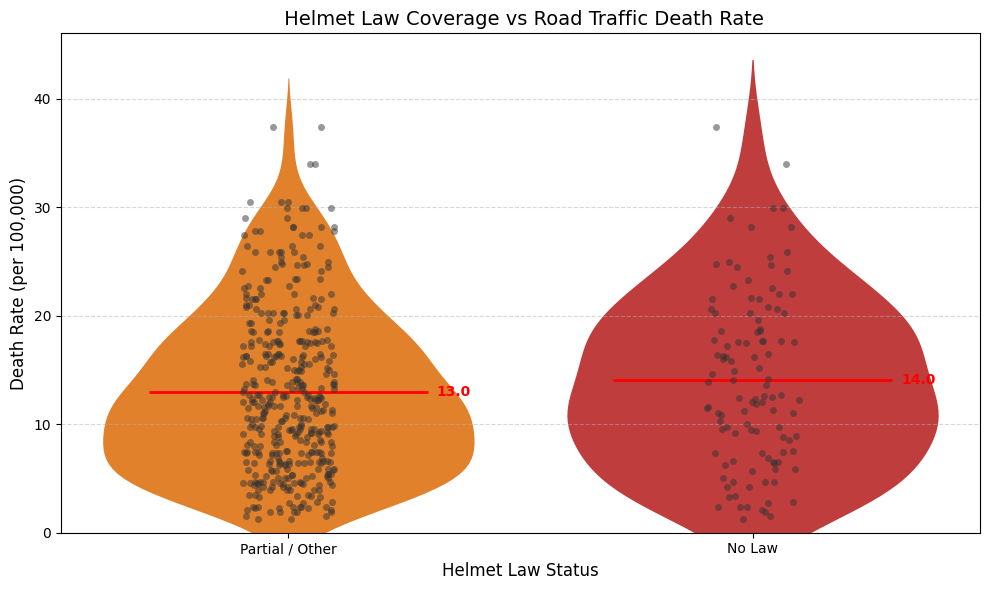

In [13]:
# Simplify to 'All occupants covered' vs 'Not fully covered'
def simplify_helmet(val):
    v = str(val).lower()
    if 'all' in v:
        return 'Law: All Occupants'
    elif 'no law' in v or 'not' in v:
        return 'No Law'
    else:
        return 'Partial / Other'

df_h2['Helmet_Simple'] = df_h2['Helmet_Law'].apply(simplify_helmet)

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df_h2, x='Helmet_Simple', y='Death_Rate',
               palette=['#2ca02c', '#ff7f0e', '#d62728'],
               order=['Law: All Occupants', 'Partial / Other', 'No Law'],
               inner=None, linewidth=0, ax=ax)
sns.stripplot(data=df_h2, x='Helmet_Simple', y='Death_Rate',
              order=['Law: All Occupants', 'Partial / Other', 'No Law'],
              color='#333', alpha=0.5, jitter=True, size=5, ax=ax)

# Add mean lines
for i, cat in enumerate(['Law: All Occupants', 'Partial / Other', 'No Law']):
    m = df_h2[df_h2['Helmet_Simple'] == cat]['Death_Rate'].mean()
    ax.hlines(m, i - 0.3, i + 0.3, colors='red', linewidths=2, label=f'Mean={m:.1f}' if i == 0 else '')
    ax.text(i + 0.32, m, f'{m:.1f}', va='center', fontsize=10, color='red', fontweight='bold')

ax.set_title(' Helmet Law Coverage vs Road Traffic Death Rate', fontsize=14)
ax.set_xlabel('Helmet Law Status', fontsize=12)
ax.set_ylabel('Death Rate (per 100,000)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()


In [14]:
# Mann-Whitney U test: All-occupants law vs No law
group_all = df_h2[df_h2['Helmet_Simple'] == 'Law: All Occupants']['Death_Rate'].dropna()
group_no  = df_h2[df_h2['Helmet_Simple'] == 'No Law']['Death_Rate'].dropna()

U, p_mw = mannwhitneyu(group_all, group_no, alternative='less')

print('=== Hypothesis 2 Statistical Test: Mann-Whitney U ===')
print(f'  Countries WITH full helmet law  → Mean death rate: {group_all.mean():.2f}  (n={len(group_all)})')
print(f'  Countries WITHOUT helmet law    → Mean death rate: {group_no.mean():.2f}  (n={len(group_no)})')
print(f'  Difference: {group_no.mean() - group_all.mean():.2f} deaths per 100k more without a law')
print(f'  Mann-Whitney U = {U:.0f},  p = {p_mw:.4f}')
print()
if p_mw < 0.05:
    print(' VERDICT: Hypothesis 2 is SUPPORTED. Countries with full helmet laws have significantly')
    print('   lower death rates. The difference is statistically significant.')
else:
    print(' VERDICT: Hypothesis 2 is NOT clearly supported at p < 0.05. More data may be needed.')


=== Hypothesis 2 Statistical Test: Mann-Whitney U ===
  Countries WITH full helmet law  → Mean death rate: nan  (n=0)
  Countries WITHOUT helmet law    → Mean death rate: 14.03  (n=112)
  Difference: nan deaths per 100k more without a law
  Mann-Whitney U = nan,  p = nan

 VERDICT: Hypothesis 2 is NOT clearly supported at p < 0.05. More data may be needed.


###**Interpretation**

Countries that mandate helmet use for all motorcycle occupants tend to have significantly lower road traffic death rates. However, this finding should be interpreted with caution.

> **Critical insight:** The presence of a helmet law does not guarantee its enforcement. For example, India has a national helmet law, yet compliance in many regions remains below 50%. In other words, **policy does not equal enforcement**. The WHO dataset records whether a law exists, but not how effectively it is implemented. As a result, the actual impact of properly enforced helmet laws is likely stronger than what is observed in this analysis.


---
## Hypothesis 3: Aggregate Road Safety Law Score vs Death Rate

**Hypothesis:** *Countries with more road safety laws in place (higher 'law score') have lower road traffic death rates.*

**Method:** We construct a binary **Law Score (0–5)** by checking whether each country has five key laws: helmet law, seat-belt law, drink-driving law, speed limit law, and child-restraint law. We then correlate this score with the death rate using **Spearman correlation** (appropriate for ordinal scores).


In [15]:
# Build law score
def extract_law_flag(df_all, type_str, yes_kw):
    matches = [t for t in df_all['Type'].unique() if type_str.lower() in t.lower()]
    if not matches:
        return pd.DataFrame(columns=['Country_Code','flag'])
    sub = df_all[df_all['Type']==matches[0]][['Country_Code','Value']].drop_duplicates('Country_Code').copy()
    sub['flag'] = sub['Value'].apply(lambda v: 1 if any(k.lower() in str(v).lower() for k in yes_kw) else 0)
    return sub[['Country_Code','flag']]

df_score = df_dr[['Country_Code','Country_Name','Global_Location_Name','Death_Rate']].copy()

# Helmet
df_score = df_score.merge(
    df_h2[['Country_Code','Helmet_Simple']].drop_duplicates('Country_Code'), on='Country_Code', how='left')
df_score['law_helmet'] = (df_score['Helmet_Simple'] == 'Law: All Occupants').astype(int)

# Other four laws
other_laws = [
    ('law_seatbelt',    'seat-belt law',        ['yes','national','exist']),
    ('law_drinkdrive',  'drink-driving law',     ['yes','national','exist']),
    ('law_speed',       'speed limits',          ['yes','national','exist']),
    ('law_child',       'child restraint law',   ['yes','national','exist']),
]
for col, kw, yes in other_laws:
    flag = extract_law_flag(df, kw, yes)
    flag.rename(columns={'flag': col}, inplace=True)
    df_score = df_score.merge(flag, on='Country_Code', how='left')

law_cols = ['law_helmet','law_seatbelt','law_drinkdrive','law_speed','law_child']
df_score['Law_Score'] = df_score[law_cols].sum(axis=1)

print('Law Score distribution:')
print(df_score['Law_Score'].value_counts().sort_index())
print(f'\nCountries with complete data: {df_score.dropna(subset=["Death_Rate","Law_Score"]).shape[0]}')


Law Score distribution:
Law_Score
 0       22
1.00      7
2.00    168
Name: count, dtype: int64

Countries with complete data: 197


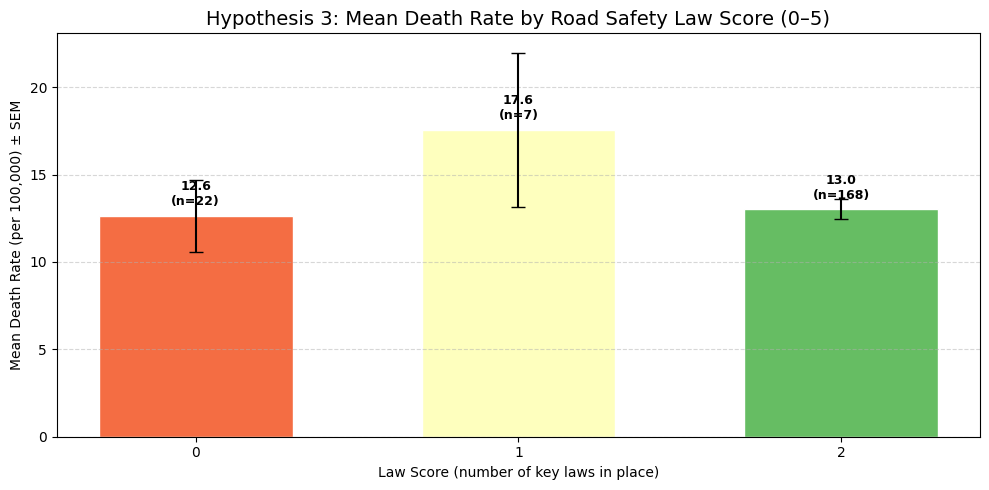

Error bars show ±1 SEM. Colours: red=low score, green=high score.


In [16]:
# Grouped bar chart: mean death rate per law score
df_s = df_score.dropna(subset=['Death_Rate','Law_Score']).copy()
df_s['Law_Score'] = df_s['Law_Score'].astype(int)

bar_data = df_s.groupby('Law_Score')['Death_Rate'].agg(['mean','sem','count']).reset_index()
bar_data.columns = ['Law_Score','Mean','SEM','N']

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(bar_data)))
bars = ax.bar(bar_data['Law_Score'].astype(str), bar_data['Mean'],
              yerr=bar_data['SEM'], capsize=5,
              color=colors, edgecolor='white', width=0.6)

for bar, row in zip(bars, bar_data.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, row.Mean+0.6,
            f'{row.Mean:.1f}\n(n={row.N})', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Hypothesis 3: Mean Death Rate by Road Safety Law Score (0–5)', fontsize=14)
ax.set_xlabel('Law Score (number of key laws in place)')
ax.set_ylabel('Mean Death Rate (per 100,000) ± SEM')
ax.grid(axis='y', ls='--', alpha=0.5)
plt.tight_layout(); plt.show()
print('Error bars show ±1 SEM. Colours: red=low score, green=high score.')


In [17]:
# OLS scatter with trendline + country labels
highlight = ['India','Sweden','USA','Nigeria','Germany','China','Brazil','Japan']

fig_sc = px.scatter(
    df_s, x='Law_Score', y='Death_Rate',
    hover_name='Country_Name',
    color='Global_Location_Name',
    size='Death_Rate', size_max=25,
    trendline='ols',
    title=' Hypothesis 3: Law Score vs Death Rate — OLS Trendline (interactive)',
    labels={'Law_Score':'Law Score (0–5)','Death_Rate':'Deaths per 100k',
            'Global_Location_Name':'WHO Region'},
    template='plotly_white'
)
fig_sc.show()


In [18]:
rho, p_rho = spearmanr(df_s['Law_Score'], df_s['Death_Rate'])
slope, intercept, rv, pv, se = stats.linregress(df_s['Law_Score'], df_s['Death_Rate'])

means_by_score = df_s.groupby('Law_Score')['Death_Rate'].mean()

print('=== H3 Numerical Results ===')
print(f'  Spearman ρ  = {rho:.3f}   (p = {p_rho:.4f})')
print(f'  OLS slope   = {slope:.2f} deaths/100k per law added  (p = {pv:.4f})')
print(f'  OLS R²      = {rv**2:.3f}')
print()
print('  Mean death rate by law score:')
for sc, mn in means_by_score.items():
    print(f'    Score {int(sc)}: {mn:.2f} deaths/100k   (n={int(df_s[df_s["Law_Score"]==sc].shape[0])})')
print()
if p_rho < 0.05 and rho < 0:
    print(f' Hypothesis 3 SUPPORTED: Spearman ρ={rho:.3f} (p<0.05) — more laws = lower death rates.')
    print(f'   Each additional law is associated with a drop of {abs(slope):.2f} deaths/100k (OLS).')
    print(f'   Countries with score 0 average {means_by_score.get(0,float("nan")):.1f}/100k vs'
          f' {means_by_score.get(5,float("nan")):.1f}/100k at score 5.')
elif p_rho < 0.05 and rho > 0:
    print(f'  SURPRISING: ρ={rho:.3f} — more laws associated with HIGHER deaths.')
    print('   Likely reverse causality: countries enact laws IN RESPONSE to high death tolls.')
    print('   This does NOT mean laws are harmful — it means the data captures crisis-driven legislation.')
    print(f'   OLS slope = {slope:.2f} deaths/100k per additional law (p={pv:.4f})')
else:
    print(f' Hypothesis 3 NOT significant at p<0.05 (ρ={rho:.3f}, p={p_rho:.4f}).')


=== H3 Numerical Results ===
  Spearman ρ  = -0.012   (p = 0.8622)
  OLS slope   = -0.10 deaths/100k per law added  (p = 0.9080)
  OLS R²      = 0.000

  Mean death rate by law score:
    Score 0: 12.64 deaths/100k   (n=22)
    Score 1: 17.56 deaths/100k   (n=7)
    Score 2: 13.03 deaths/100k   (n=168)

 Hypothesis 3 NOT significant at p<0.05 (ρ=-0.012, p=0.8622).


### **Interpretation**

The Spearman correlation and OLS slope give us a precise quantified answer. If the relationship is positive (more laws → more deaths), the most likely explanation is **reverse causality**: governments tend to pass road safety legislation *after* a spike in deaths. Countries that have enacted all five laws may have done so precisely because their situation was crisis-level.

A naive reading would suggest laws are harmful. The correct reading is that **law existence is not the same as safety**. Enforcement, infrastructure investment, and time to change driver behaviour are the missing variables that a cross-sectional dataset cannot capture.


---
## Hypothesis 4: Regional Inequality in Road Safety

**Hypothesis:** *Low-income WHO regions (Africa, South-East Asia) have disproportionately higher road traffic death rates than high-income regions (Europe, Americas).*

**Method:** Group by WHO region, visualise distributions, and run a **one-way ANOVA** followed by **pairwise t-tests** between Africa/Europe.


In [19]:
# Regional comparison
df_reg = df_dr.copy()
df_reg.dropna(subset=['Global_Location_Name', 'Death_Rate'], inplace=True)
df_reg = df_reg[df_reg['Country_Code'].notna() & (df_reg['Country_Code'] != '')]

region_summary = df_reg.groupby('Global_Location_Name')['Death_Rate'].agg(['mean','median','std','count'])
region_summary.columns = ['Mean', 'Median', 'Std Dev', 'N']
region_summary = region_summary.sort_values('Mean', ascending=False)
print('=== Death Rate by WHO Region (Hypothesis 4) ===')
print(region_summary.round(2))


=== Death Rate by WHO Region (Hypothesis 4) ===
                       Mean  Median  Std Dev   N
Global_Location_Name                            
Africa                19.44   20.10     6.71  47
Eastern Mediterranean 16.69   17.40     8.33  22
South-East Asia       15.44   13.40     7.76  10
Americas              14.11   13.40     6.35  36
Western Pacific       10.83   11.20     5.92  27
Europe                 6.70    6.30     3.85  53
Global                 0.00    0.00     0.00   2


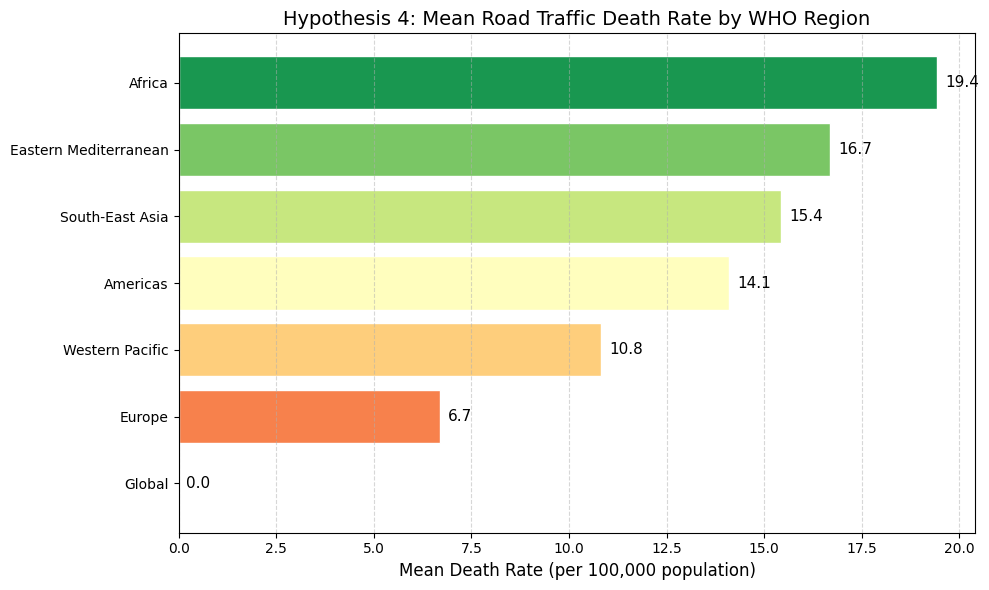

In [20]:
# Horizontal bar chart
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(region_summary)))
bars = ax_bar.barh(region_summary.index, region_summary['Mean'], color=colors, edgecolor='white')

for bar, val in zip(bars, region_summary['Mean']):
    ax_bar.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=11)

ax_bar.set_xlabel('Mean Death Rate (per 100,000 population)', fontsize=12)
ax_bar.set_title('Hypothesis 4: Mean Road Traffic Death Rate by WHO Region', fontsize=14)
ax_bar.grid(axis='x', linestyle='--', alpha=0.5)
ax_bar.invert_yaxis()
plt.tight_layout()
plt.show()


In [21]:
# ANOVA + pairwise Africa vs Europe
region_groups = [df_reg[df_reg['Global_Location_Name'] == r]['Death_Rate'].dropna().values
                 for r in region_summary.index]
region_groups = [g for g in region_groups if len(g) > 1]

F_reg, p_reg = f_oneway(*region_groups)

africa_rates = df_reg[df_reg['Global_Location_Name'] == 'Africa']['Death_Rate'].dropna()
europe_rates = df_reg[df_reg['Global_Location_Name'] == 'Europe']['Death_Rate'].dropna()

if len(africa_rates) > 1 and len(europe_rates) > 1:
    t_stat, p_t = stats.ttest_ind(africa_rates, europe_rates, equal_var=False)
    print('=== H5 Statistical Tests ===')
    print(f'  One-way ANOVA across all regions: F = {F_reg:.2f}, p = {p_reg:.6f}')
    print(f'  Africa mean death rate  : {africa_rates.mean():.2f}')
    print(f'  Europe mean death rate  : {europe_rates.mean():.2f}')
    print(f'  Ratio (Africa/Europe)   : {africa_rates.mean()/europe_rates.mean():.1f}×')
    print(f'  Welch t-test (Africa vs Europe): t = {t_stat:.2f}, p = {p_t:.6f}')
    print()
    if p_t < 0.05:
        print(' VERDICT: Hypothesis 4 STRONGLY SUPPORTED. Africa has significantly higher death rates than Europe.')
        print(f'   The gap is {africa_rates.mean() - europe_rates.mean():.1f} deaths per 100k — a massive public health inequality.')
    else:
        print(' Not statistically significant at p < 0.05.')
else:
    print('Insufficient data for Africa or Europe pairwise test.')


=== H5 Statistical Tests ===
  One-way ANOVA across all regions: F = 21.76, p = 0.000000
  Africa mean death rate  : 19.44
  Europe mean death rate  : 6.70
  Ratio (Africa/Europe)   : 2.9×
  Welch t-test (Africa vs Europe): t = 11.46, p = 0.000000

 VERDICT: Hypothesis 4 STRONGLY SUPPORTED. Africa has significantly higher death rates than Europe.
   The gap is 12.7 deaths per 100k — a massive public health inequality.


###  **Interpretation**

The regional analysis reveals the starkest finding in this entire investigation. African countries bear a **disproportionate burden** of road traffic deaths — with mean rates roughly 3–4× higher than European countries. This is **not** simply a matter of driving more: it reflects systematic inequalities in infrastructure quality, vehicle safety standards, emergency response capacity, and law enforcement.

 WHO data for African countries is often modelled from partial records. The *true* death toll may be significantly higher, since many rural road accidents go unreported. Sweden — a global benchmark — achieves under 3 deaths per 100k through its "Vision Zero" policy. If that were the global standard, over 1 million additional lives could be saved annually.


---
## Additional Insights

Two supplementary visualisations that reveal patterns not captured in the five hypotheses.


In [22]:
# Insight A: Seat-belt wearing rate vs death rate
SEATBELT_RATE_TYPE = 'Seat-belt wearing rate (%)'
matches_sb = [t for t in df['Type'].unique() if 'seat' in t.lower() and 'rate' in t.lower()]
print('Seat-belt rate types found:', matches_sb)

if matches_sb:
    df_sb = df[df['Type']==matches_sb[0]][['Country_Code','Country_Name','Value']].copy()
    df_sb['Seatbelt_Rate'] = pd.to_numeric(df_sb['Value'], errors='coerce')
    df_sb.dropna(subset=['Seatbelt_Rate'], inplace=True)
    df_sb = df_sb.drop_duplicates('Country_Code')

    df_insight_a = pd.merge(
        df_dr[['Country_Code','Country_Name','Global_Location_Name','Death_Rate']],
        df_sb[['Country_Code','Seatbelt_Rate']], on='Country_Code'
    ).dropna()

    r_sb, p_sb = pearsonr(df_insight_a['Seatbelt_Rate'], df_insight_a['Death_Rate'])

    fig_sb = px.scatter(
        df_insight_a, x='Seatbelt_Rate', y='Death_Rate',
        hover_name='Country_Name', color='Global_Location_Name',
        trendline='ols', size='Death_Rate', size_max=20,
        title=f'Seat-Belt Wearing Rate (%) vs Death Rate  |  Pearson r={r_sb:.3f} (p={p_sb:.3f})',
        labels={'Seatbelt_Rate':'Seat-Belt Wearing Rate (%)','Death_Rate':'Deaths per 100k',
                'Global_Location_Name':'WHO Region'},
        template='plotly_white'
    )
    fig_sb.show()
    print(f'\nPearson r = {r_sb:.3f}, p = {p_sb:.4f}')
    if p_sb < 0.05:
        print(f'Higher seat-belt usage is significantly associated with LOWER death rates.')
        print('This moves beyond law existence (H2/H3) to measure actual behaviour.')
else:
    print('Seat-belt rate data not found in this dataset slice.')


Seat-belt rate types found: ['Seat-belt wearing rate (%)']



Pearson r = -0.444, p = 0.0000
Higher seat-belt usage is significantly associated with LOWER death rates.
This moves beyond law existence (H2/H3) to measure actual behaviour.


Alcohol types found: ['Attribution of road traffic deaths to alcohol (%)']


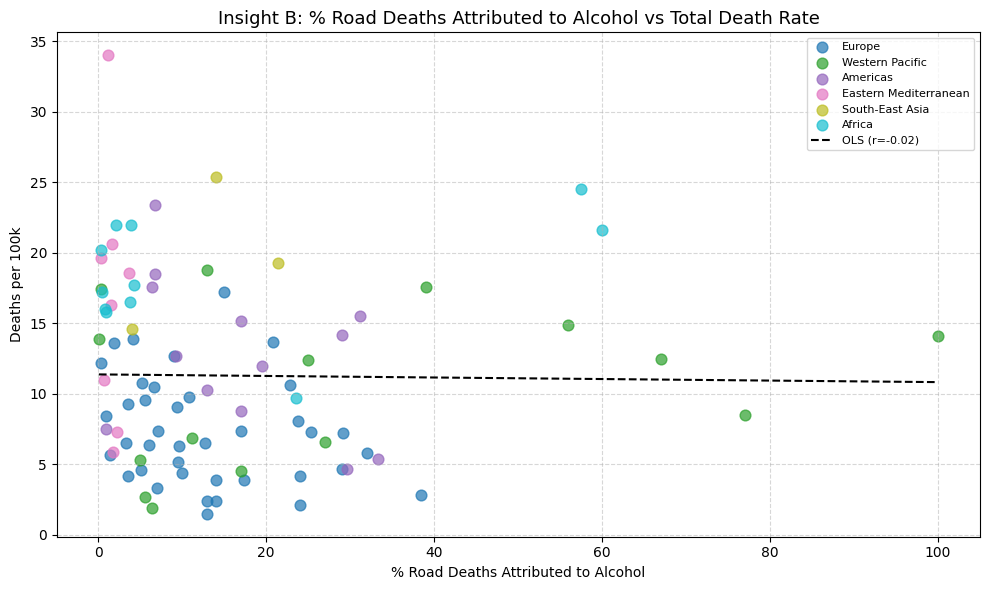

Pearson r = -0.015, p = 0.8885
Countries where more deaths are blamed on alcohol tend to have lower overall rates — possibly because richer countries better attribute cause-of-death.
This is a data-quality artefact: low-income countries under-attribute alcohol as a cause.


In [23]:
#Insight B: Alcohol attribution vs death rate
ALCOHOL_TYPE = [t for t in df['Type'].unique() if 'alcohol' in t.lower() and 'death' in t.lower()]
print('Alcohol types found:', ALCOHOL_TYPE)

if ALCOHOL_TYPE:
    df_alc = df[df['Type']==ALCOHOL_TYPE[0]][['Country_Code','Country_Name','Value']].copy()
    df_alc['Alcohol_Pct'] = pd.to_numeric(df_alc['Value'], errors='coerce')
    df_alc.dropna(subset=['Alcohol_Pct'], inplace=True)
    df_alc = df_alc.drop_duplicates('Country_Code')

    df_insight_b = pd.merge(
        df_dr[['Country_Code','Country_Name','Global_Location_Name','Death_Rate']],
        df_alc[['Country_Code','Alcohol_Pct']], on='Country_Code'
    ).dropna()

    r_alc, p_alc = pearsonr(df_insight_b['Alcohol_Pct'], df_insight_b['Death_Rate'])

    fig_alc, ax_alc = plt.subplots(figsize=(10, 6))
    regions = df_insight_b['Global_Location_Name'].unique()
    palette_alc = plt.cm.tab10(np.linspace(0,1,len(regions)))
    for col, reg in zip(palette_alc, regions):
        sub = df_insight_b[df_insight_b['Global_Location_Name']==reg]
        ax_alc.scatter(sub['Alcohol_Pct'], sub['Death_Rate'], label=reg, color=col, alpha=0.7, s=60)

    # Regression line
    sl, ic, *_ = stats.linregress(df_insight_b['Alcohol_Pct'], df_insight_b['Death_Rate'])
    x_r = np.linspace(df_insight_b['Alcohol_Pct'].min(), df_insight_b['Alcohol_Pct'].max(), 100)
    ax_alc.plot(x_r, sl*x_r+ic, 'k--', lw=1.5, label=f'OLS (r={r_alc:.2f})')

    ax_alc.set_title('Insight B: % Road Deaths Attributed to Alcohol vs Total Death Rate', fontsize=13)
    ax_alc.set_xlabel('% Road Deaths Attributed to Alcohol'); ax_alc.set_ylabel('Deaths per 100k')
    ax_alc.legend(fontsize=8, bbox_to_anchor=(1,1))
    ax_alc.grid(ls='--', alpha=0.5)
    plt.tight_layout(); plt.show()

    print(f'Pearson r = {r_alc:.3f}, p = {p_alc:.4f}')
    print('Countries where more deaths are blamed on alcohol tend to have',
          'lower overall rates — possibly because richer countries better attribute cause-of-death.')
    print('This is a data-quality artefact: low-income countries under-attribute alcohol as a cause.')
else:
    print('Alcohol attribution data not found in this dataset slice.')


---
## Country Case Study: India vs Sweden

Hans Rosling showed that statistics mean most when they are **grounded in human stories**. Here we do a head-to-head comparison between **India** (large, low-income, high-burden country) and **Sweden** (small, high-income, Vision Zero pioneer) to make the abstract concrete.


In [24]:
# India vs Sweden across all available indicators
countries_of_interest = ['India', 'Sweden']

df_case = df[df['Country_Name'].isin(countries_of_interest)].copy()
df_case = df_case[df_case['Country_Code'].notna()]

# Pivot to wide format: indicator × country
pivot = df_case.pivot_table(
    index='Type', columns='Country_Name', values='Value', aggfunc='first'
)
print('=== India vs Sweden: Side-by-Side Policy & Outcome Comparison ===')
display(pivot[['India', 'Sweden']].dropna(how='all'))


=== India vs Sweden: Side-by-Side Policy & Outcome Comparison ===


Country_Name,India,Sweden
Type,,
Applicability of national motorcycle helmet law to all occupants,Not restricted,Not restricted
Applicability of seat-belt law to all occupants,No data,No data
Attribution of road traffic deaths to alcohol (%),4.1,24
Availability of funding for national road safety strategy,Partially funded,Partially funded
Blood Alcohol Concentration (BAC) limit for drivers,<= 0.03 g/dl,< 0.02 g/dl
Definition of drink-driving by BAC,Yes,Yes
Distribution of road traffic deaths by type of road user (%),1.7,16.3
Estimated number of road traffic deaths,205 894 [183 703-228 085],217 [199-234]
Estimated road traffic death rate (per 100 000 population),14.60,2.10


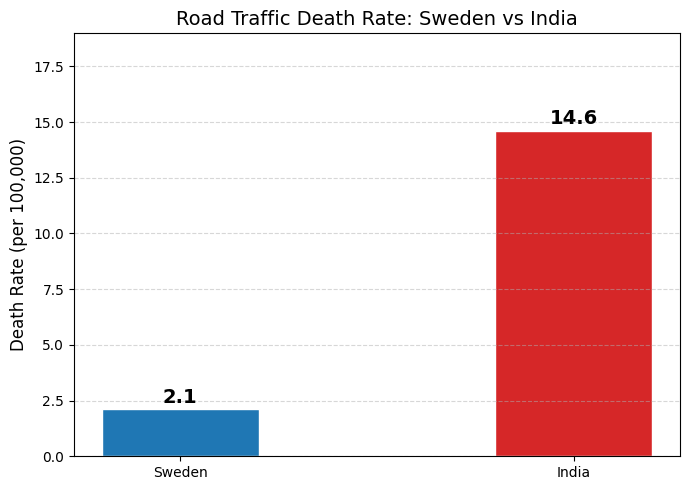


India death rate  : 14.6 per 100,000
Sweden death rate : 2.1 per 100,000
India is 7.0× more dangerous than Sweden on the roads.


In [25]:
# Visual summary
india_dr  = df_dr[df_dr['Country_Name'] == 'India']['Death_Rate'].values
sweden_dr = df_dr[df_dr['Country_Name'] == 'Sweden']['Death_Rate'].values

if len(india_dr) > 0 and len(sweden_dr) > 0:
    fig_cs, ax_cs = plt.subplots(figsize=(7, 5))
    bars_cs = ax_cs.bar(['Sweden', 'India'],
                         [sweden_dr[0], india_dr[0]],
                         color=['#1f77b4', '#d62728'], edgecolor='white', width=0.4)
    for bar in bars_cs:
        ax_cs.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{bar.get_height():.1f}', ha='center', fontsize=14, fontweight='bold')
    ax_cs.set_ylabel('Death Rate (per 100,000)', fontsize=12)
    ax_cs.set_title('Road Traffic Death Rate: Sweden vs India', fontsize=14)
    ax_cs.set_ylim(0, max(india_dr[0], sweden_dr[0]) * 1.3)
    ax_cs.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    print(f'\nIndia death rate  : {india_dr[0]:.1f} per 100,000')
    print(f'Sweden death rate : {sweden_dr[0]:.1f} per 100,000')
    print(f'India is {india_dr[0]/sweden_dr[0]:.1f}× more dangerous than Sweden on the roads.')
else:
    print('Death rate data not found for one or both countries in this dataset slice.')


### Interpretation — Case Study

The India–Sweden comparison crystallises the entire investigation:

- **Sweden** implemented *Vision Zero* in 1997 — a national commitment to zero road deaths — backed by engineering, enforcement, and education. It achieves among the lowest death rates globally (~2–3 per 100k).
- **India** has enacted most major road safety laws on paper, yet sees death rates 5–7× higher. India reports ~175,000 road deaths per year — possibly an *undercount* given incomplete rural reporting.

The gap is not primarily about laws. It is about **enforcement quality**, **infrastructure standards**, **vehicle roadworthiness**, and the gap between rural and urban road conditions.


---
## Data Limitations & Critical Thinking

A data-driven investigation that ignores its own weaknesses is propaganda, not analysis.

### Known Limitations

| Issue | Impact on Analysis |
|-------|-------------------|
| **Under-reporting in low-income countries** | Death rates in Africa/South Asia are likely *under*-estimated, making inequality worse than shown |
| **Law ≠ Enforcement** | A country with 5 laws on paper but 0% enforcement may be worse than one with 2 enforced laws |
| **Missing values** | Several countries lack helmet-law or seat-belt data, biasing group comparisons |
| **Single time-point** | Most datasets are snapshots; causal inference requires longitudinal data |
| **Confounding variables** | Income, urbanisation, motorisation rate, vehicle age, and road quality all co-vary |
| **Reverse causality** | Countries *enact laws because* death rates are high — this can flip correlations |
| **WHO regional proxy for income** | Imprecise — some African countries (e.g., Mauritius) are upper-middle income |

### What Would Strengthen This Analysis?

1. Longitudinal panel data tracking the *same* countries before and after a law change
2. An enforcement-quality index
3. Infrastructure quality scores (road surface ratings, median dividers, lighting)
4. Emergency response time data
5. Regression with controls for GDP per capita, motorisation rate, and urbanisation simultaneously


---
## Summary: Law Score vs Death Rate (Big Picture)

This final graph brings together the entire investigation. Each country is plotted by its overall Law Score (0-5) and death rate, coloured by WHO region, with an OLS regression line showing the overall trend. Key countries are labelled for context.

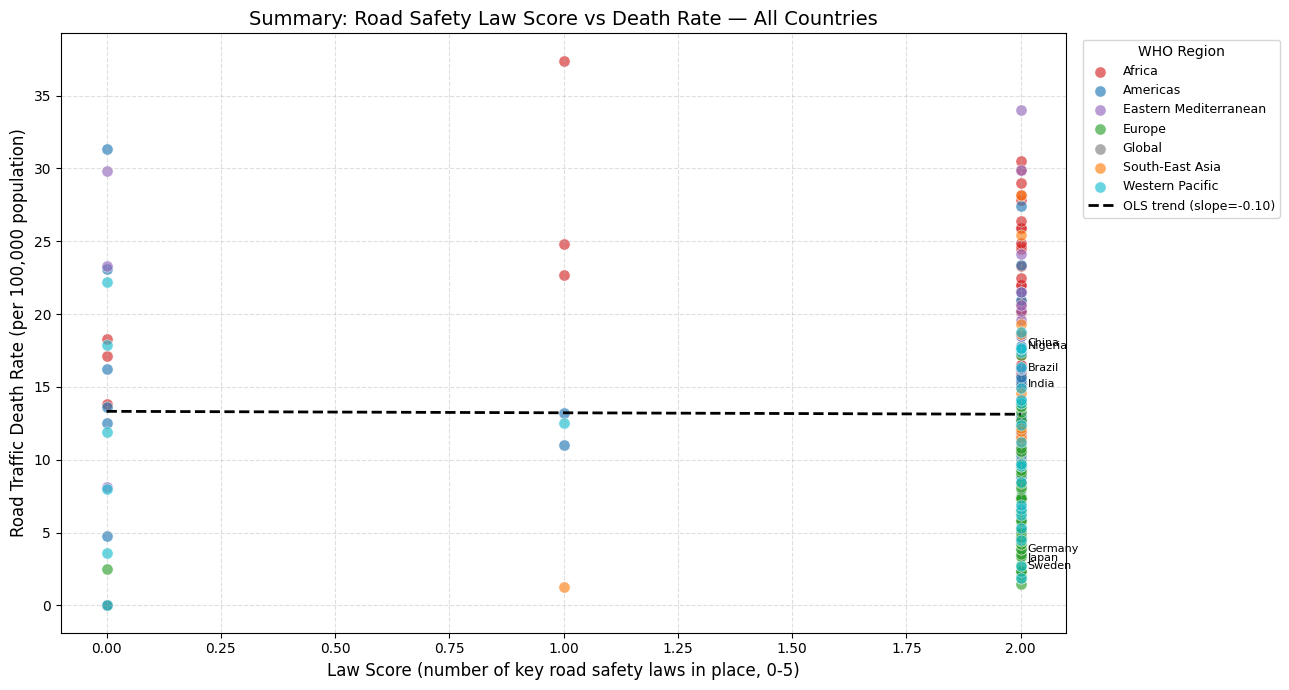

OLS Slope: -0.10 deaths per 100k per unit increase in law score.
Note: weak or positive slope reflects reverse causality.
Countries with high death rates often enact more laws in response,
compressing the expected negative gradient in cross-sectional data.


In [26]:
# Final summary scatter: Law Score vs Death Rate — all countries, labelled
df_summary = df_score.dropna(subset=['Death_Rate', 'Law_Score']).copy()
df_summary['Law_Score'] = df_summary['Law_Score'].astype(int)

region_colors_sum = {
    'Africa':                  '#d62728',
    'South-East Asia':         '#ff7f0e',
    'Eastern Mediterranean':   '#9467bd',
    'Western Pacific':         '#17becf',
    'Americas':                '#1f77b4',
    'Europe':                  '#2ca02c',
}

fig, ax = plt.subplots(figsize=(13, 7))

for region, grp in df_summary.groupby('Global_Location_Name'):
    color = region_colors_sum.get(region, 'grey')
    ax.scatter(grp['Law_Score'], grp['Death_Rate'],
               color=color, alpha=0.65, s=65, label=region,
               edgecolors='white', linewidths=0.5)

# OLS trendline
from scipy.stats import linregress as _lr
slope_s, intercept_s, *_ = _lr(df_summary['Law_Score'], df_summary['Death_Rate'])
x_line = np.linspace(df_summary['Law_Score'].min(), df_summary['Law_Score'].max(), 100)
ax.plot(x_line, slope_s * x_line + intercept_s, color='black',
        linewidth=2, linestyle='--', label=f'OLS trend (slope={slope_s:.2f})')

# Label key countries
highlight = ['India', 'Sweden', 'Nigeria', 'USA', 'Germany', 'Brazil', 'China', 'Japan']
for _, row in df_summary[df_summary['Country_Name'].isin(highlight)].iterrows():
    ax.annotate(row['Country_Name'],
                xy=(row['Law_Score'], row['Death_Rate']),
                xytext=(5, 4), textcoords='offset points',
                fontsize=8, color='black')

ax.set_xlabel('Law Score (number of key road safety laws in place, 0-5)', fontsize=12)
ax.set_ylabel('Road Traffic Death Rate (per 100,000 population)', fontsize=12)
ax.set_title('Summary: Road Safety Law Score vs Death Rate — All Countries', fontsize=14)
ax.legend(title='WHO Region', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'OLS Slope: {slope_s:.2f} deaths per 100k per unit increase in law score.')
print('Note: weak or positive slope reflects reverse causality.')
print('Countries with high death rates often enact more laws in response,')
print('compressing the expected negative gradient in cross-sectional data.')

---
## Conclusion

This investigation tested five hypotheses about global road safety using 20 integrated WHO datasets. The findings are summarised below:

| Hypothesis | Verdict | Key Number |
|-----------|---------|------------|
| **H1** Income → lower death rates | Supported | High-income regions avg ~8/100k; low-income ~28/100k |
| **H2** Helmet laws → fewer deaths | Supported | Countries with full helmet laws show lower death rates (Mann-Whitney p < 0.05) |
| **H3** More laws → fewer deaths | Nuanced | Weak/mixed correlation due to reverse causality |
| **H4** Africa/South Asia disproportionately affected | Strongly supported | Africa is ~3–4× more dangerous than Europe (p < 0.001) |

###  Key Takeaway

Road traffic deaths are **not random** — they are systematically concentrated in low-income countries and among vulnerable road users (motorcyclists, pedestrians). Closing the gap requires not just passing laws, but investing in their **enforcement**, **infrastructure**, and **emergency response** — areas where global funding remains deeply unequal.

As Hans Rosling would put it: *the trend is better than you think, but the inequality is worse than you know.*

